# Isotypic symmetry ties vs orbit auto-ties

This notebook ablates three `koopman="graph"` configurations on small
automorphism-rich graphs:

1. **Isotypic** — `koopman_symmetry="isotypic"` (exact $\mathrm{Aut}(G)$
   orbits for $K_{\mathrm{self}}$; requires `pynauty`)
2. **Orbit auto** — `koopman_auto_orbits=True` (WL / networkx
   `method="auto"`; `[symmetry]`)
3. **Shared baseline** — default single shared $K_{\mathrm{self}}$ (no
   multi-orbit bank)

The primary fixture is a **star** (two orbits: hub vs leaves). Relative to
that shared baseline, two Aut orbits allocate **two** $K_{\mathrm{self}}$
banks — more operator parameters, with a stricter inductive bias. Relative to
a per-node identity partition, the same ties **reduce** capacity. A **cycle**
gives a secondary check where Aut acts transitively (one orbit), so tied and
shared parameter counts match.

**Claim discipline.** Orbit / isotypic ties are an inductive bias on
$K_{\mathrm{self}}$ capacity, not a guaranteed sample-efficiency win. This
notebook claims a holdout one-step RMSE win only when the mean gap vs shared
clears `RMSE_WIN_EPS` across reported seeds. Near-ties and losses are stated
plainly.

**Prerequisites**

```bash
pip install "koopman-graph[symmetry]"   # networkx for auto orbits
pip install pynauty                      # exact Aut / isotypic path
```

Without `pynauty`, the notebook still runs: auto-orbit vs shared arms
execute; the isotypic arm is skipped with an explicit message. Theory:
Salova et al., *Chaos* 2019 (`Salova2019`); isotypic projectors use the
permutation representation of $\mathrm{Aut}(G)$.


## Setup


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import importlib.util
import os
import random

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch

import koopman_graph
from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.datasets.dynamics import (
    diffusion_sequence_from_features,
    laplacian_diffusion_rollout,
    make_generator,
)
from koopman_graph.graph_utils import node_orbit_partition
from koopman_graph.operators import GraphKoopmanOperator

try:
    import networkx  # noqa: F401

    SYMMETRY_AVAILABLE = True
except ImportError:
    SYMMETRY_AVAILABLE = False

HAS_PYNAUTY = importlib.util.find_spec("pynauty") is not None

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 45
SEEDS = (SEED,) if IS_TEST else (45, 46, 47)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

N_STAR = 5 if IS_TEST else 9
N_CYCLE = 6 if IS_TEST else 8
LATENT_DIM = 2 if IS_TEST else 4
FEATURES = 2
EPOCHS = 2 if IS_TEST else 25
T_TRAIN = 16 if IS_TEST else 40
HOLDOUT = 4 if IS_TEST else 8
# Absolute holdout one-step RMSE margin before claiming a win.
RMSE_WIN_EPS = 0.02

print(f"koopman_graph {koopman_graph.__version__}; torch {torch.__version__}")
print(
    f"IS_TEST={IS_TEST}  SYMMETRY_AVAILABLE={SYMMETRY_AVAILABLE}  "
    f"HAS_PYNAUTY={HAS_PYNAUTY}"
)
print(f"N_star={N_STAR}  N_cycle={N_CYCLE}  d={LATENT_DIM}  seeds={SEEDS}")
if not SYMMETRY_AVAILABLE:
    print('Install orbits backend: pip install "koopman-graph[symmetry]"')
if not HAS_PYNAUTY:
    print("pynauty missing: isotypic arm will be skipped (auto vs shared only).")


koopman_graph 0.11.0; torch 2.13.0
IS_TEST=False  SYMMETRY_AVAILABLE=True  HAS_PYNAUTY=True
N_star=9  N_cycle=8  d=4  seeds=(45, 46, 47)


## Motivation

Default `koopman="graph"` already shares one $K_{\mathrm{self}}$ across
nodes. On a **star**, exact automorphism orbits allocate **two** banks (hub;
leaves). That is a stricter inductive bias than a single shared factor: it
**increases** trainable operator parameters vs the shared baseline (one extra
$K_{\mathrm{self}}$ block) while remaining far cheaper than a per-node
identity partition.

`koopman_auto_orbits=True` approximates orbits via Weisfeiler–Lehman coloring
when `networkx` is available (`method="auto"`). `koopman_symmetry="isotypic"`
forces the **exact** $\mathrm{Aut}(G)$ partition (and stores the isotypic
decomposition for diagnostics). On many small stars and cycles the two
partitions agree; they need not agree on graphs where WL is incomplete.


## Minimal example: star operator banks

Bind isotypic (when `pynauty` is present), auto-orbit, and shared operators on
a bidirectional star. Hub and leaves form distinct $\mathrm{Aut}(G)$ orbits.
Compare trainable operator parameter counts before any training loop.

When isotypic binding succeeds, the notebook also prints isotypic dimensions from
the permutation representation of $\mathrm{Aut}(G)$ (`Salova2019`). For a star,
$\mathrm{Aut}\cong S_{N-1}$ typically yields the leaf standard irrep (dimension
$N-2$) plus two 1-D trivial pieces (hub; leaf-constant mode)—for example
`(7, 1, 1)` when $N=9$.


Shared helpers for graph construction, diffusion sequences, and trainable
parameter counts.


In [2]:
def star_edge_index(num_nodes: int) -> torch.Tensor:
    edges: list[list[int]] = []
    for leaf in range(1, num_nodes):
        edges.extend([[0, leaf], [leaf, 0]])
    return torch.tensor(edges, dtype=torch.long).t().contiguous()


def cycle_edge_index(num_nodes: int) -> torch.Tensor:
    src, dst = [], []
    for i in range(num_nodes):
        j = (i + 1) % num_nodes
        src.extend([i, j])
        dst.extend([j, i])
    return torch.tensor([src, dst], dtype=torch.long)


def make_diffusion_sequence(
    edge_index: torch.Tensor,
    *,
    num_nodes: int,
    num_timesteps: int,
    seed: int,
) -> object:
    features = laplacian_diffusion_rollout(
        edge_index=edge_index,
        num_nodes=num_nodes,
        num_timesteps=num_timesteps,
        in_channels=FEATURES,
        diffusion_rate=0.35,
        decay_rate=0.92,
        noise_std=0.0,
        initial_state="ones",
        dtype=torch.float32,
        generator=make_generator(seed),
    )
    return diffusion_sequence_from_features(features, edge_index)


def trainable_params(module: torch.nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


In [3]:
star_ei = star_edge_index(N_STAR)
if SYMMETRY_AVAILABLE:
    star_auto_part = node_orbit_partition(star_ei, N_STAR, method="auto")
else:
    star_auto_part = None
print(f"star auto partition: {star_auto_part}")

star_shared = GraphKoopmanOperator(LATENT_DIM, init_mode="identity")
star_auto = GraphKoopmanOperator(
    LATENT_DIM, init_mode="identity", auto_orbits=True
)
_ = star_auto.advance(torch.zeros(N_STAR, LATENT_DIM), edge_index=star_ei)

star_param_counts = {
    "auto_orbits": trainable_params(star_auto),
    "shared": trainable_params(star_shared),
}

if HAS_PYNAUTY:
    star_iso = GraphKoopmanOperator(
        LATENT_DIM, init_mode="identity", isotypic_symmetry=True
    )
    _ = star_iso.advance(torch.zeros(N_STAR, LATENT_DIM), edge_index=star_ei)
    star_param_counts["isotypic"] = trainable_params(star_iso)
    print(f"star isotypic partition: {star_iso.orbit_partition}")
    iso_dims = (
        star_iso.isotypic_decomposition.dimensions
        if star_iso.isotypic_decomposition
        else None
    )
    print(f"isotypic dimensions: {iso_dims}")
else:
    print("Skipping isotypic operator bind (pynauty unavailable).")

print("Operator trainable parameters (star):")
for name, n in star_param_counts.items():
    print(f"  {name:16s}  {n}")
if star_param_counts["auto_orbits"] > star_param_counts["shared"]:
    print(
        "Note: multi-orbit banks exceed the shared baseline count "
        f"({star_param_counts['auto_orbits']} > {star_param_counts['shared']}); "
        "they reduce capacity only vs a per-node identity partition."
    )


star auto partition: ((0,), (1, 2, 3, 4, 5, 6, 7, 8))
star isotypic partition: ((0,), (1, 2, 3, 4, 5, 6, 7, 8))
isotypic dimensions: (7, 1, 1)
Operator trainable parameters (star):
  auto_orbits       48
  shared            32
  isotypic          48
Note: multi-orbit banks exceed the shared baseline count (48 > 32); they reduce capacity only vs a per-node identity partition.


## Progressive deep dive: cycle parameter counts

On a cycle, $\mathrm{Aut}(C_n)$ acts transitively — one orbit — so exact
isotypic / auto-orbit $K_{\mathrm{self}}$ banks match the **count** of the
default shared operator. This cell only reports parameter counts (no fit).


In [4]:
cycle_ei = cycle_edge_index(N_CYCLE)
cycle_shared = GraphKoopmanOperator(LATENT_DIM, init_mode="identity")
cycle_auto = GraphKoopmanOperator(
    LATENT_DIM, init_mode="identity", auto_orbits=True
)
_ = cycle_auto.advance(torch.zeros(N_CYCLE, LATENT_DIM), edge_index=cycle_ei)

cycle_param_counts = {
    "auto_orbits": trainable_params(cycle_auto),
    "shared": trainable_params(cycle_shared),
}
if SYMMETRY_AVAILABLE:
    print(
        f"cycle auto partition: "
        f"{node_orbit_partition(cycle_ei, N_CYCLE, method='auto')}"
    )
if HAS_PYNAUTY:
    cycle_iso = GraphKoopmanOperator(
        LATENT_DIM, init_mode="identity", isotypic_symmetry=True
    )
    _ = cycle_iso.advance(torch.zeros(N_CYCLE, LATENT_DIM), edge_index=cycle_ei)
    cycle_param_counts["isotypic"] = trainable_params(cycle_iso)
    print(f"cycle isotypic partition: {cycle_iso.orbit_partition}")

print("Operator trainable parameters (cycle):")
for name, n in cycle_param_counts.items():
    print(f"  {name:16s}  {n}")
assert cycle_param_counts["auto_orbits"] == cycle_param_counts["shared"]
if "isotypic" in cycle_param_counts:
    assert cycle_param_counts["isotypic"] == cycle_param_counts["shared"]
print("Cycle: tied banks match shared parameter count (one orbit).")


cycle auto partition: ((0, 1, 2, 3, 4, 5, 6, 7),)
cycle isotypic partition: ((0, 1, 2, 3, 4, 5, 6, 7),)
Operator trainable parameters (cycle):
  auto_orbits       32
  shared            32
  isotypic          32
Cycle: tied banks match shared parameter count (one orbit).


## Progressive deep dive: star holdout ablation

Fit isotypic (if available), auto-orbit, and shared models with identical
encoder/decoder width and epoch count (matched optimization budget — not
matched operator capacity). Evaluate chronological holdout **one-step RMSE**.
Report mean $\pm$ std across `SEEDS`. Claim a sample-efficiency win only if
the mean RMSE of a tied model beats shared by at least `RMSE_WIN_EPS`;
otherwise report a non-claim.


Model factory and holdout one-step RMSE helper for the seed loop below.


In [5]:
def make_model(*, mode: str) -> GraphKoopmanModel:
    kwargs = dict(
        encoder=GNNEncoder(FEATURES, 16, LATENT_DIM, num_layers=2),
        decoder=GNNDecoder(LATENT_DIM, 16, FEATURES, num_layers=2),
        latent_dim=LATENT_DIM,
        time_step=1.0,
        koopman="graph",
    )
    if mode == "isotypic":
        return GraphKoopmanModel(**kwargs, koopman_symmetry="isotypic")
    if mode == "auto":
        return GraphKoopmanModel(
            **kwargs,
            koopman_auto_orbits=True,
            koopman_orbit_method="auto",
        )
    if mode == "shared":
        return GraphKoopmanModel(**kwargs)
    raise ValueError(mode)


def one_step_rmse(model: GraphKoopmanModel, sequence) -> float:
    errs = []
    model.eval()
    with torch.no_grad():
        for t in range(sequence.num_timesteps - 1):
            pred = model(sequence[t])
            target = sequence[t + 1].x
            errs.append(torch.mean((pred - target) ** 2))
    return float(torch.sqrt(torch.stack(errs).mean()).item())


In [6]:
modes = ["auto", "shared"]
if HAS_PYNAUTY:
    modes = ["isotypic", "auto", "shared"]
elif not SYMMETRY_AVAILABLE:
    modes = ["shared"]
    print("No [symmetry]: only shared baseline will be fit.")

rows: dict[str, list[float]] = {m: [] for m in modes}
param_rows: dict[str, int] = {}

for seed in SEEDS:
    full = make_diffusion_sequence(
        star_ei,
        num_nodes=N_STAR,
        num_timesteps=T_TRAIN + HOLDOUT,
        seed=seed,
    )
    train = full.slice(0, T_TRAIN)
    hold = full.slice(T_TRAIN, T_TRAIN + HOLDOUT)
    for mode in modes:
        torch.manual_seed(seed)
        model = make_model(mode=mode)
        _ = model.fit(train, epochs=EPOCHS, lr=1e-3)
        rmse = one_step_rmse(model, hold)
        rows[mode].append(rmse)
        param_rows[mode] = trainable_params(model.koopman)

print("Per-seed holdout one-step RMSE:")
header = f"{'seed':>6s}" + "".join(f"{m:>12s}" for m in modes)
print(header)
for i, seed in enumerate(SEEDS):
    line = f"{seed:6d}" + "".join(f"{rows[m][i]:12.6f}" for m in modes)
    print(line)

print("Star holdout one-step RMSE (mean ± std over seeds):")
summary = {}
for mode in modes:
    vals = np.asarray(rows[mode], dtype=float)
    mean = float(vals.mean())
    std = float(vals.std(ddof=0))
    summary[mode] = {"mean": mean, "std": std, "op_params": param_rows[mode]}
    print(
        f"  {mode:10s}  RMSE={mean:.6f} ± {std:.6f}  "
        f"op_params={param_rows[mode]}  n_seeds={len(vals)}"
    )

shared_mean = summary["shared"]["mean"]
for mode in modes:
    if mode == "shared":
        continue
    gap = shared_mean - summary[mode]["mean"]
    if gap >= RMSE_WIN_EPS:
        print(
            f"Claim: {mode} beats shared on mean holdout RMSE by "
            f"{gap:.4f} (≥ RMSE_WIN_EPS={RMSE_WIN_EPS})."
        )
    else:
        print(
            f"Non-claim: {mode} vs shared mean gap={gap:.4f} "
            f"(need ≥ {RMSE_WIN_EPS}); multi-orbit ties are an inductive "
            f"bias on K_self banks, not a guaranteed sample-efficiency win."
        )


Per-seed holdout one-step RMSE:
  seed    isotypic        auto      shared
    45    0.020238    0.020238    0.020288
    46    0.060700    0.060700    0.061132
    47    0.035653    0.035653    0.035574
Star holdout one-step RMSE (mean ± std over seeds):
  isotypic    RMSE=0.038864 ± 0.016674  op_params=48  n_seeds=3
  auto        RMSE=0.038864 ± 0.016674  op_params=48  n_seeds=3
  shared      RMSE=0.038998 ± 0.016849  op_params=32  n_seeds=3
Non-claim: isotypic vs shared mean gap=0.0001 (need ≥ 0.02); multi-orbit ties are an inductive bias on K_self banks, not a guaranteed sample-efficiency win.
Non-claim: auto vs shared mean gap=0.0001 (need ≥ 0.02); multi-orbit ties are an inductive bias on K_self banks, not a guaranteed sample-efficiency win.


## Results

**Left:** operator parameter counts on the star. On a two-orbit star, isotypic
and auto-orbit bars sit **above** the shared baseline (extra $K_{\mathrm{self}}$
bank); isotypic is omitted when `pynauty` is absent.

**Right:** mean holdout one-step RMSE $\pm$ std across seeds. When Aut and WL
partitions agree, isotypic and auto means coincide; the shared mean often
differs only in the fourth decimal, so the bars look identical at plot scale.
The annotation reports `shared − mode` mean gaps. Read the per-seed RMSE table
and claim gate in stdout before interpreting the bars as a sample-efficiency
win.


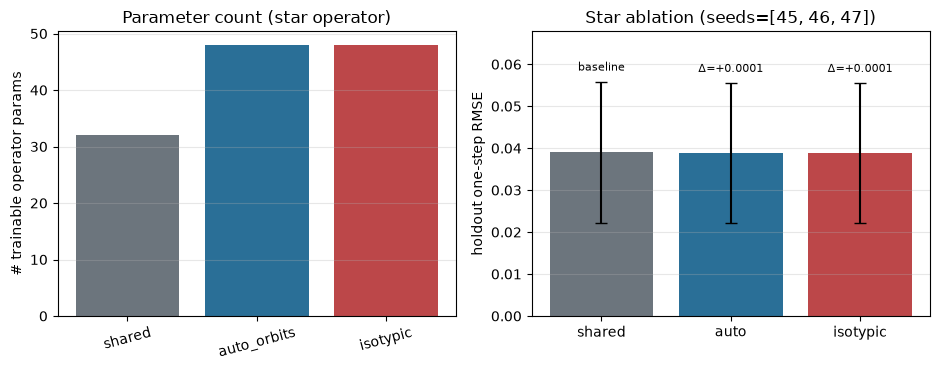

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))

count_colors = {
    "shared": "#6c757d",
    "auto_orbits": "#2a6f97",
    "isotypic": "#bc4749",
}
mode_colors = {
    "shared": "#6c757d",
    "auto": "#2a6f97",
    "isotypic": "#bc4749",
}

# Stable legend order: shared baseline, then tied arms when present.
count_order = [
    k
    for k in ("shared", "auto_orbits", "isotypic")
    if k in star_param_counts
]
axes[0].bar(
    count_order,
    [star_param_counts[k] for k in count_order],
    color=[count_colors[k] for k in count_order],
)
axes[0].set_ylabel("# trainable operator params")
axes[0].set_title("Parameter count (star operator)")
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)

mode_order = [m for m in ("shared", "auto", "isotypic") if m in summary]
means = [summary[m]["mean"] for m in mode_order]
stds = [summary[m]["std"] for m in mode_order]
bars = axes[1].bar(
    mode_order,
    means,
    yerr=stds,
    capsize=4,
    color=[mode_colors[m] for m in mode_order],
)
axes[1].set_ylabel("holdout one-step RMSE")
axes[1].set_title(f"Star ablation (seeds={list(SEEDS)})")
axes[1].grid(axis="y", alpha=0.3)

# Annotate mean gaps vs shared so near-ties are readable at plot scale.
shared_mean = summary["shared"]["mean"]
ymax = max(m + s for m, s in zip(means, stds))
for rect, mode in zip(bars, mode_order):
    if mode == "shared":
        label = "baseline"
    else:
        gap = shared_mean - summary[mode]["mean"]
        label = f"Δ={gap:+.4f}"
    axes[1].text(
        rect.get_x() + rect.get_width() / 2,
        rect.get_height() + summary[mode]["std"] + 0.002,
        label,
        ha="center",
        va="bottom",
        fontsize=8,
    )
axes[1].set_ylim(0.0, ymax + 0.012)
fig.tight_layout()
plt.show()


## Interpretation

- **Capacity vs shared baseline:** on the star, two Aut orbits ⇒ two
  $K_{\mathrm{self}}$ banks for isotypic / (typically) auto orbits, so
  trainable operator parameters **exceed** the single shared bank. That is an
  inductive bias (orbit-homogeneous self-maps), not a parameter-count win vs
  default `koopman="graph"`.
- **Capacity vs per-node:** the same two-bank construction remains far smaller
  than an identity partition (one bank per node). Prefer that contrast when
  discussing “parameter reduction.”
- **Cycle check:** one orbit ⇒ tied banks match the shared parameter count;
  prefer the star when asking whether multi-orbit ties change capacity.
- **Sample efficiency** is seed- and budget-dependent. Only claim a win when
  the mean holdout RMSE gap clears `RMSE_WIN_EPS`; otherwise report a
  non-claim. Negative or near-tie results are expected on short budgets.
- **WL vs exact:** `method="auto"` can mis-tie blocks on graphs where
  Weisfeiler–Lehman is incomplete. Isotypic ties use exact $\mathrm{Aut}(G)$
  via `pynauty` and refuse WL for the representation path (`Salova2019`).


## Takeaways

- Use `koopman_symmetry="isotypic"` when you want exact Aut orbit
  $K_{\mathrm{self}}$ ties and stored isotypic dimensions (install
  `pynauty`).
- Use `koopman_auto_orbits=True` for the lighter `[symmetry]` / networkx path.
- Default shared $K_{\mathrm{self}}$ remains a strong baseline; on
  multi-orbit graphs (stars) it often has **fewer** operator parameters than
  orbit/isotypic banks.
- On stars where WL and exact Aut partitions agree, expect isotypic and auto
  holdout RMSE to match; shared may still look identical at plot scale when
  the mean gap is $\ll$ `RMSE_WIN_EPS` — use the per-seed table and $\Delta$
  annotations.
- Report operator parameter counts beside errors; do not equate a different
  (often higher) orbit-bank count with a guaranteed sample-efficiency win.
- Citations (`paper.bib`): `Salova2019`.


## Further reading

- Related tutorial:
  [`35_symmetry_adapted_operator.ipynb`](35_symmetry_adapted_operator.ipynb)
  (orbit ties, KS ring, sample-budget gate)
- [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html) —
  `koopman_symmetry`, `koopman_auto_orbits`, `compute_isotypic_decomposition`
- [Architecture](https://koopmangraph.readthedocs.io/en/latest/architecture.html) —
  symmetry-adapted operators
- Salova et al., *Chaos* **29**, 093128 (2019),
  doi:[10.1063/1.5099091](https://doi.org/10.1063/1.5099091)
  (`paper.bib`: `Salova2019`)
